In [1]:
import os
import sys
import numpy as np
import re

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [2]:
condition = "3mod_s126_sd"
n_samples_test = 100
split = "test"
dataset = "form_50_35_15_cgc_0_20"

def get_saved_epochs(root_path, project_name, experiment_name):
    pattern = f"{root_path}/checkpoints/{project_name}/{experiment_name}/checkpoints/save-epoch=*.ckpt"
    paths = glob.glob(pattern)
    epochs = []
    for p in paths:
        match = re.search(r'save-epoch=(\d+)\.ckpt', p)
        if match:
            epochs.append(int(match.group(1)))
    return sorted(epochs)

experiment_name = get_experiment_name(condition, dataset, 0)
saved_epochs = get_saved_epochs(root_path, "syn", experiment_name)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

epochs = saved_epochs[0:15]
results_per_epoch = {}

for checkpoint_epoch in epochs:
    with total_silence():
        global_workspace, domain_mods, gw_mod, visual_module, original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=experiment_name,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch
            )
        objects = get_objects_from_v_latents(
            latent_domains, gw_mod, global_workspace, modules_name, start_v=False
        )

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']

    colors_np = objects['x2']['color'].detach().cpu().numpy()
    cats = cat.argmax(dim=1).detach().cpu().numpy()

    metrics, _ = hue_analysis(colors_np, cats, cat_names=CAT_NAMES, value=0.75, saturation_boost=1.8)
    results_per_epoch[checkpoint_epoch] = metrics



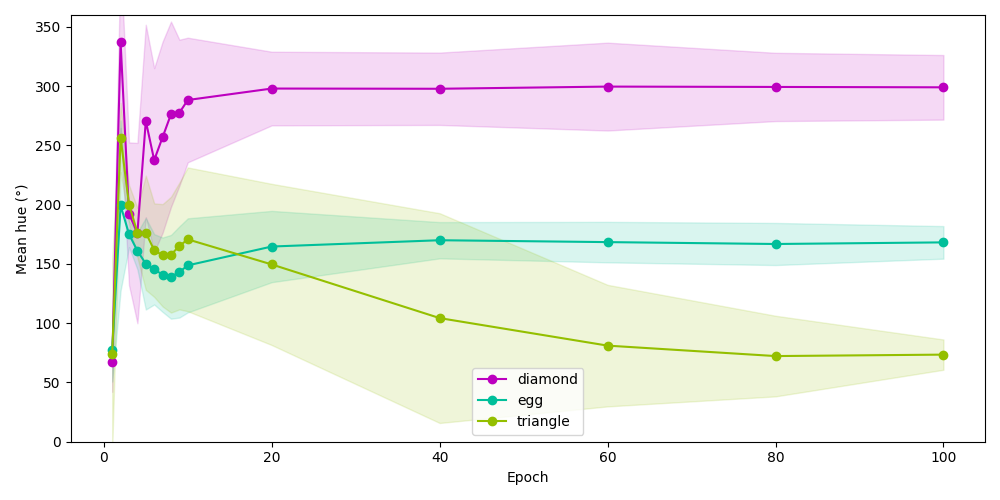

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import colorsys

# --- Couleurs finales par catégorie ---
def boost_color(rgb_0_1: np.ndarray, value: float, saturation_boost: float):
    h, s, v = colorsys.rgb_to_hsv(*rgb_0_1)
    s = min(1.0, s * saturation_boost)
    return colorsys.hsv_to_rgb(h, s, value)

def hue_to_boosted_rgb(mean_hue_deg, value=0.75, saturation_boost=1.8):
    h = mean_hue_deg / 360.0
    rgb = colorsys.hsv_to_rgb(h, 1.0, 1.0)
    return boost_color(np.array(rgb), value, saturation_boost)

def split_on_jumps(epochs_list, hue_series, threshold=180):
    """Insert NaN where hue jumps by more than threshold degrees."""
    xs, ys = [epochs_list[0]], [hue_series[0]]
    for i in range(1, len(hue_series)):
        diff = abs(hue_series[i] - hue_series[i-1])
        jump = min(diff, 360 - diff)  # distance circulaire réelle
        if jump > threshold:
            xs.append(None)
            ys.append(None)
        xs.append(epochs_list[i])
        ys.append(hue_series[i])
    return xs, ys

last_epoch = epochs[-1]
cat_ids = list(results_per_epoch[last_epoch]['per_cat'].keys())
cat_colors = {
    c: hue_to_boosted_rgb(results_per_epoch[last_epoch]['per_cat'][c]['mean_hue'])
    for c in cat_ids
}

mean_hues = {
    c: [results_per_epoch[e]['per_cat'][c]['mean_hue'] for e in epochs]
    for c in cat_ids
}

# --- Graphique ---
fig, ax1 = plt.subplots(figsize=(10, 5))

for cat_id in cat_ids:
    name = CAT_NAMES[cat_id]
    color = cat_colors[cat_id]
    hues = mean_hues[cat_id]

    xs, ys = split_on_jumps(list(epochs), hues)
    ax1.plot(xs, ys, marker='o', label=name, color=color)

    std_hues = [results_per_epoch[e]['per_cat'][cat_id]['std_hue'] for e in epochs]
    ax1.fill_between(
        list(epochs),
        [h - s for h, s in zip(hues, std_hues)],
        [h + s for h, s in zip(hues, std_hues)],
        alpha=0.15, color=color
    )

ax1.set_ylim(0, 360)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean hue (°)')
ax1.legend(loc='best')
plt.tight_layout()
plt.show()